In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

#Paths 
RAW   = "data_raw/"
CLEAN = "data_clean/"

#FRED API
load_dotenv()
FRED_KEY = os.environ["FRED_API_KEY"]

#Sample window
START =  "2015-01-01"
END = "2024-12-31"

In [10]:
#Fred fetch function
def fetch_fred(series_id, nickname):
    url = (
        f"https://api.stlouisfed.org/fred/series/observations"
        f"?series_id={series_id}"
        f"&observation_start={START}"
        f"&observation_end={END}"
        f"&api_key={FRED_KEY}"
        f"&file_type=json"
    )
    r = requests.get(url)
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["date", nickname]
    df["date"] = pd.to_datetime(df["date"])
    df[nickname] = pd.to_numeric(df[nickname], errors="coerce")
    df = df.set_index("date")
    df.to_csv(f"{RAW}{nickname}.csv")
    print(f"{nickname}: {len(df)} rows pulled, saved to {RAW}{nickname}.csv")
    return df
#Pull the three FRED series 
copper = fetch_fred("PCOPPUSDM", "copper")
exports = fetch_fred("XTEXVA01CNM657S", "exports")



copper: 120 rows pulled, saved to data_raw/copper.csv
exports: 120 rows pulled, saved to data_raw/exports.csv


In [11]:
# ── NBS Manufacturing PMI (China official, hardcoded from public NBS releases) ──
# Source: National Bureau of Statistics of China, Jan 2015 – Dec 2024
pmi_data = {
    "2015-01-01": 49.8, "2015-02-01": 49.9, "2015-03-01": 50.1, "2015-04-01": 50.1,
    "2015-05-01": 50.2, "2015-06-01": 50.2, "2015-07-01": 50.0, "2015-08-01": 49.7,
    "2015-09-01": 49.8, "2015-10-01": 49.8, "2015-11-01": 49.6, "2015-12-01": 49.7,
    "2016-01-01": 49.4, "2016-02-01": 49.0, "2016-03-01": 50.2, "2016-04-01": 50.1,
    "2016-05-01": 50.1, "2016-06-01": 50.0, "2016-07-01": 49.9, "2016-08-01": 50.4,
    "2016-09-01": 50.4, "2016-10-01": 50.8, "2016-11-01": 51.7, "2016-12-01": 51.4,
    "2017-01-01": 51.3, "2017-02-01": 51.6, "2017-03-01": 51.8, "2017-04-01": 51.2,
    "2017-05-01": 51.2, "2017-06-01": 51.7, "2017-07-01": 51.4, "2017-08-01": 51.7,
    "2017-09-01": 52.4, "2017-10-01": 51.6, "2017-11-01": 51.8, "2017-12-01": 51.6,
    "2018-01-01": 51.3, "2018-02-01": 50.3, "2018-03-01": 51.5, "2018-04-01": 51.1,
    "2018-05-01": 51.9, "2018-06-01": 51.5, "2018-07-01": 51.2, "2018-08-01": 51.3,
    "2018-09-01": 50.8, "2018-10-01": 50.2, "2018-11-01": 50.0, "2018-12-01": 49.4,
    "2019-01-01": 49.5, "2019-02-01": 49.2, "2019-03-01": 50.5, "2019-04-01": 50.1,
    "2019-05-01": 49.4, "2019-06-01": 49.4, "2019-07-01": 49.7, "2019-08-01": 49.5,
    "2019-09-01": 49.8, "2019-10-01": 49.3, "2019-11-01": 50.2, "2019-12-01": 50.2,
    "2020-01-01": 50.0, "2020-02-01": 35.7, "2020-03-01": 52.0, "2020-04-01": 50.8,
    "2020-05-01": 50.6, "2020-06-01": 50.9, "2020-07-01": 51.1, "2020-08-01": 51.0,
    "2020-09-01": 51.5, "2020-10-01": 51.4, "2020-11-01": 52.1, "2020-12-01": 51.9,
    "2021-01-01": 51.3, "2021-02-01": 50.6, "2021-03-01": 51.9, "2021-04-01": 51.1,
    "2021-05-01": 51.0, "2021-06-01": 50.9, "2021-07-01": 50.4, "2021-08-01": 50.1,
    "2021-09-01": 49.6, "2021-10-01": 49.2, "2021-11-01": 50.1, "2021-12-01": 50.3,
    "2022-01-01": 50.1, "2022-02-01": 50.2, "2022-03-01": 49.5, "2022-04-01": 47.4,
    "2022-05-01": 49.6, "2022-06-01": 50.2, "2022-07-01": 49.0, "2022-08-01": 49.4,
    "2022-09-01": 50.1, "2022-10-01": 49.2, "2022-11-01": 48.0, "2022-12-01": 47.0,
    "2023-01-01": 50.1, "2023-02-01": 52.6, "2023-03-01": 51.9, "2023-04-01": 49.2,
    "2023-05-01": 48.8, "2023-06-01": 49.0, "2023-07-01": 49.3, "2023-08-01": 49.7,
    "2023-09-01": 50.2, "2023-10-01": 49.5, "2023-11-01": 49.4, "2023-12-01": 49.0,
    "2024-01-01": 49.2, "2024-02-01": 49.1, "2024-03-01": 50.8, "2024-04-01": 50.4,
    "2024-05-01": 49.5, "2024-06-01": 49.5, "2024-07-01": 49.4, "2024-08-01": 49.1,
    "2024-09-01": 49.8, "2024-10-01": 50.1, "2024-11-01": 50.3, "2024-12-01": 50.1,
}

pmi = pd.DataFrame.from_dict(pmi_data, orient="index", columns=["pmi"])
pmi.index = pd.to_datetime(pmi.index)
pmi.index.name = "date"
pmi.to_csv(f"{RAW}pmi.csv")
print(f"pmi: {len(pmi)} rows hardcoded, saved to {RAW}pmi.csv")

pmi: 120 rows hardcoded, saved to data_raw/pmi.csv


In [12]:
#Step 2: Load, merge, clean 

# Load all four series
copper  = pd.read_csv(f"{RAW}copper.csv",  index_col="date", parse_dates=True)
exports = pd.read_csv(f"{RAW}exports.csv", index_col="date", parse_dates=True)
bci     = pd.read_csv(f"{RAW}bci.csv",     index_col="date", parse_dates=True)
pmi     = pd.read_csv(f"{RAW}pmi.csv",     index_col="date", parse_dates=True)

# Merge on date index (inner join keeps only months present in all four)
df = copper.join([exports, bci, pmi], how="inner")

# Forward-fill missing values (max 1 month gap)
df = df.ffill(limit=1)

# Drop any remaining NaNs
df = df.dropna()

# Compute 3-month copper return
df["copper_3m"] = df["copper"].pct_change(3)

# Save clean file
df.to_csv(f"{CLEAN}df_clean.csv")

print(df.shape)
print(df.head())
print(f"\nMissing values:\n{df.isnull().sum()}")

(120, 5)
                 copper    exports  bci   pmi  copper_3m
date                                                    
2015-01-01  5830.535714   0.498077 -0.4  49.8        NaN
2015-02-01  5729.275000  29.202060 -0.2  49.9        NaN
2015-03-01  5939.670455 -36.218170  0.2  50.1        NaN
2015-04-01  6042.087500  11.772740  0.2  50.1   0.036283
2015-05-01  6294.776316   4.160822  0.4  50.2   0.098704

Missing values:
copper       0
exports      0
bci          0
pmi          0
copper_3m    3
dtype: int64


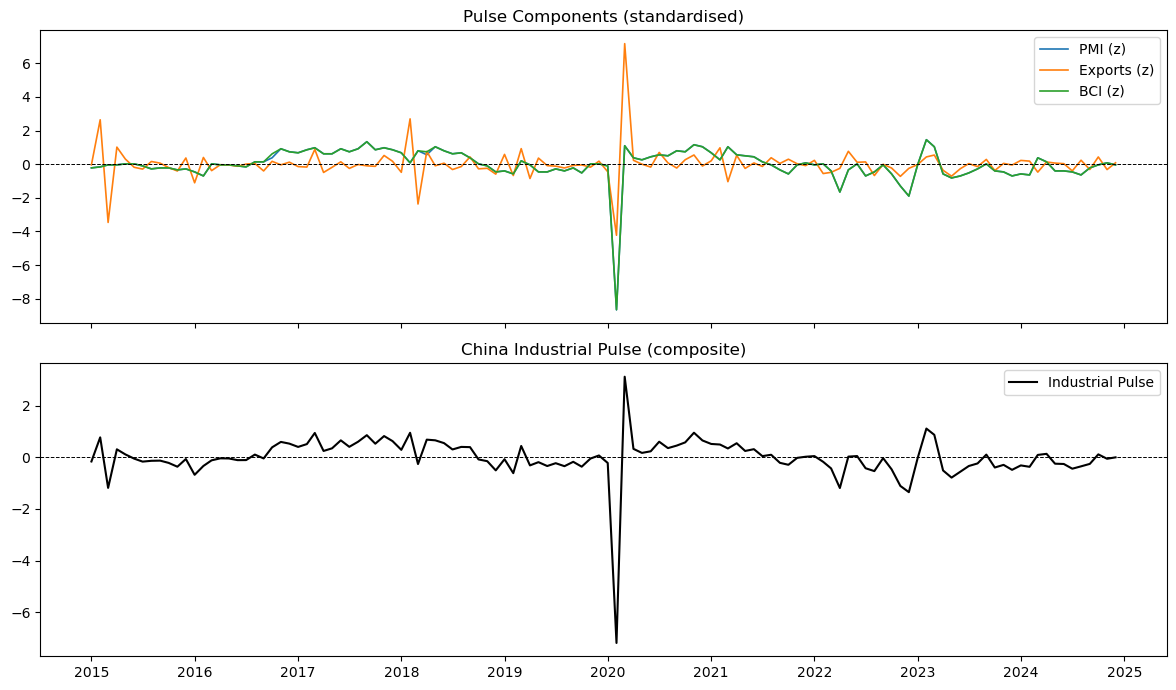

Plot saved.


In [13]:
#Step 3: Construct Industrial Pulse

# Z-score each component (standardise to mean=0, std=1)
def zscore(series):
    return (series - series.mean()) / series.std()

df["pmi_z"]     = zscore(df["pmi"])
df["exports_z"] = zscore(df["exports"])
df["bci_z"]     = zscore(df["bci"])

# Equal-weight average of the three z-scores
df["pulse"] = df[["pmi_z", "exports_z", "bci_z"]].mean(axis=1)

# Quick sense-check plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: individual components
axes[0].plot(df.index, df["pmi_z"],     label="PMI (z)", linewidth=1.2)
axes[0].plot(df.index, df["exports_z"], label="Exports (z)", linewidth=1.2)
axes[0].plot(df.index, df["bci_z"],     label="BCI (z)", linewidth=1.2)
axes[0].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[0].set_title("Pulse Components (standardised)")
axes[0].legend()

# Bottom: composite pulse
axes[1].plot(df.index, df["pulse"], color="black", linewidth=1.5, label="Industrial Pulse")
axes[1].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[1].set_title("China Industrial Pulse (composite)")
axes[1].legend()

plt.tight_layout()
plt.savefig("pulse_components.png", dpi=150)
plt.show()
print("Plot saved.")

In [14]:
df.to_csv(f"{CLEAN}df_clean.csv")
print("Clean file updated with pulse.")

Clean file updated with pulse.


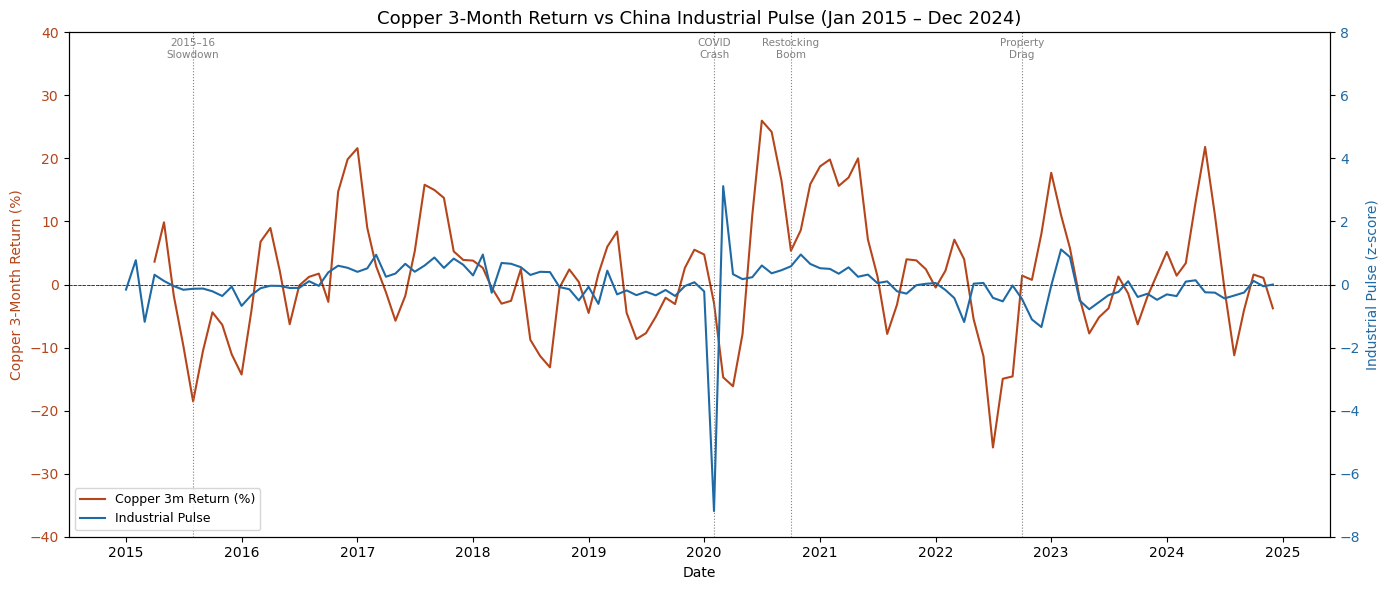

Main chart saved.


In [15]:
#Step 4: Main Chart — Copper 3m Return vs Industrial Pulse

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: copper 3m return
ax1.plot(df.index, df["copper_3m"] * 100, color="#b5451b", linewidth=1.5, label="Copper 3m Return (%)")
ax1.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax1.set_ylabel("Copper 3-Month Return (%)", color="#b5451b")
ax1.tick_params(axis="y", labelcolor="#b5451b")
ax1.set_ylim(-40, 40)

# Right axis: Industrial Pulse
ax2 = ax1.twinx()
ax2.plot(df.index, df["pulse"], color="#1f6aa5", linewidth=1.5, label="Industrial Pulse")
ax2.axhline(0, color="#1f6aa5", linewidth=0.4, linestyle="--")
ax2.set_ylabel("Industrial Pulse (z-score)", color="#1f6aa5")
ax2.tick_params(axis="y", labelcolor="#1f6aa5")
ax2.set_ylim(-8, 8)

# Mark key episodes
episodes = {
    "2015–16\nSlowdown":  "2015-08-01",
    "COVID\nCrash":       "2020-02-01",
    "Restocking\nBoom":   "2020-10-01",
    "Property\nDrag":     "2022-10-01",
}
for label, date in episodes.items():
    ax1.axvline(pd.Timestamp(date), color="grey", linewidth=0.8, linestyle=":")
    ax1.text(pd.Timestamp(date), 36, label, fontsize=7.5, color="grey", ha="center")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("Copper 3-Month Return vs China Industrial Pulse (Jan 2015 – Dec 2024)", fontsize=13)
ax1.set_xlabel("Date")

plt.tight_layout()
plt.savefig("copper_vs_pulse.png", dpi=150)
plt.show()
print("Main chart saved.")


In [16]:
#Step 5: Lead-Lag Analysis

# Define a copper rise episode: copper_3m crosses above +5% from below
threshold = 0.05

# Identify months where copper_3m exceeds threshold
copper_rise = df["copper_3m"] > threshold

# Find episode starts: current month above threshold, previous month below
episode_starts = []
for i in range(1, len(df)):
    if copper_rise.iloc[i] and not copper_rise.iloc[i-1]:
        episode_starts.append(df.index[i])

print(f"Number of copper rise episodes: {len(episode_starts)}")

# For each episode, check if pulse rises in next 1, 2, 3 months
# "Pulse rises" = pulse goes above its value at episode start
results = {1: [], 2: [], 3: []}

for date in episode_starts:
    pulse_at_start = df.loc[date, "pulse"]
    for horizon in [1, 2, 3]:
        future_dates = [date + pd.DateOffset(months=h) for h in range(1, horizon+1)]
        future_dates = [d for d in future_dates if d in df.index]
        if future_dates:
            # Check if pulse is higher than at episode start at any point in window
            future_pulse = df.loc[future_dates, "pulse"].max()
            results[horizon].append(future_pulse > pulse_at_start)

# Report hit rates
print("\nHit rates — share of copper rise episodes followed by pulse rise:")
print(f"  Within 1 month: {sum(results[1])}/{len(results[1])} = {sum(results[1])/len(results[1]):.0%}")
print(f"  Within 2 months: {sum(results[2])}/{len(results[2])} = {sum(results[2])/len(results[2]):.0%}")
print(f"  Within 3 months: {sum(results[3])}/{len(results[3])} = {sum(results[3])/len(results[3]):.0%}")

Number of copper rise episodes: 11

Hit rates — share of copper rise episodes followed by pulse rise:
  Within 1 month: 4/11 = 36%
  Within 2 months: 6/11 = 55%
  Within 3 months: 7/11 = 64%


In [17]:
#Sensitivity check: threshold = 3%, to see if the results are robust 

threshold_low = 0.03

copper_rise_low = df["copper_3m"] > threshold_low

episode_starts_low = []
for i in range(1, len(df)):
    if copper_rise_low.iloc[i] and not copper_rise_low.iloc[i-1]:
        episode_starts_low.append(df.index[i])

print(f"Number of copper rise episodes (3% threshold): {len(episode_starts_low)}")

results_low = {1: [], 2: [], 3: []}

for date in episode_starts_low:
    pulse_at_start = df.loc[date, "pulse"]
    for horizon in [1, 2, 3]:
        future_dates = [date + pd.DateOffset(months=h) for h in range(1, horizon+1)]
        future_dates = [d for d in future_dates if d in df.index]
        if future_dates:
            future_pulse = df.loc[future_dates, "pulse"].max()
            results_low[horizon].append(future_pulse > pulse_at_start)

print("\nHit rates (3% threshold):")
print(f"  Within 1 month: {sum(results_low[1])}/{len(results_low[1])} = {sum(results_low[1])/len(results_low[1]):.0%}")
print(f"  Within 2 months: {sum(results_low[2])}/{len(results_low[2])} = {sum(results_low[2])/len(results_low[2]):.0%}")
print(f"  Within 3 months: {sum(results_low[3])}/{len(results_low[3])} = {sum(results_low[3])/len(results_low[3]):.0%}")

Number of copper rise episodes (3% threshold): 12

Hit rates (3% threshold):
  Within 1 month: 6/12 = 50%
  Within 2 months: 8/12 = 67%
  Within 3 months: 9/12 = 75%


## R2 — Copper and China's Industrial Pulse: Interpretation

### Question and mechanism
This analysis asks whether movements in copper prices tend to precede shifts in China's 
industrial momentum, and if so, by how much and how reliably. The proposed mechanism is 
straightforward: copper demand reflects expected manufacturing activity, and restocking 
phases can lift prices ahead of coincident activity measures. A rise in copper should 
therefore signal an incoming acceleration in China's industrial pulse within one to three 
months.

### Evidence
The Industrial Pulse was constructed as an equal-weighted average of three standardised 
monthly series: China NBS Manufacturing PMI, China export growth (MoM, SA), and the OECD 
China Manufacturing Business Confidence Index. Copper was expressed as a 3-month rolling 
return. The sample covers January 2015 to December 2024, yielding 120 monthly observations 
and 11 copper rise episodes (defined as the 3-month return crossing above +5%).

The hit rate — the share of copper rise episodes followed by a pulse rise — increases with 
the horizon: 36% within one month, 55% within two months, and 64% within three months. 
These results are robust to a lower threshold of +3%, which yields hit rates of 50%, 67%, 
and 75% respectively. The rising pattern across horizons is consistent with a lagged 
relationship, but the 1-month hit rate is too weak to suggest a tight or mechanical lead.

### Interpretation
The evidence supports a moderate tendency for copper to lead China's industrial pulse by 
two to three months, but with important caveats. First, the relationship fails in roughly 
one in three episodes, making it insufficient as a standalone trading signal. Second, two 
episodes illustrate the main sources of breakdown. During 2015–16, copper fell sharply 
while the pulse remained relatively stable — a period when US dollar strength depressed 
copper independently of China-specific demand conditions. Third, the COVID crash of early 
2020 represents a simultaneous collapse in both series — an exogenous shock where no 
leading indicator holds.

### Positioning implications and caveats
Where the signal does hold — particularly during normal restocking cycles such as the 
2020–21 recovery — early copper strength would benefit cyclical sector exposures: 
materials, industrials, and energy. Factor tilts toward value and small-cap within those 
sectors tend to outperform during reflationary phases that copper anticipates. However, 
confidence in any copper-based signal should be conditioned on dollar direction and the 
absence of exogenous shocks. A copper rise accompanied by a weakening dollar and stable 
credit conditions is a stronger signal than one occurring against a backdrop of dollar 
strength or financial stress.